### Produce the intersection of DEG plot

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
intersection_df  <- read.csv("04A_intersect_analysis_results.csv", row.names = 1)
intersection_df %>% head()

,cell_type,contrast1,contrast2,up_both,down_both,up_1_down_2,down_1_up_2,consistent_ratio,z_score,p_value
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
0,Cardiomyocyte,HCM,development,733,489,436,163,0.6710599,14.841260,1.000000e-16
1,Cardiomyocyte,ICM,development,205,167,118,89,0.6424870,7.006677,2.440492e-12
2,Cardiomyocyte,DCM,development,324,436,171,164,0.6940639,11.952205,1.000000e-16
3,Endothelial,HCM,development,399,338,108,100,0.7798942,15.077746,1.000000e-16
4,Endothelial,ICM,development,412,229,115,71,0.7750907,14.217408,1.000000e-16
5,Endothelial,DCM,development,230,334,53,184,0.7041199,11.274377,1.000000e-16


In [3]:
intersection_df$contrast_pair <- paste0(intersection_df$contrast1, "-", intersection_df$contrast2)

In [4]:
intersection_df$contrast_pair

[1] "HCM-development" "ICM-development" "DCM-development" "HCM-development"
 [5] "ICM-development" "DCM-development" "HCM-development" "ICM-development"
 [9] "DCM-development" "HCM-development" "ICM-development" "DCM-development"
[13] "HCM-development" "ICM-development" "DCM-development" "HCM-development"
[17] "ICM-development" "DCM-development" "HCM-development" "ICM-development"
[21] "DCM-development" "HCM-development" "ICM-development" "DCM-development"

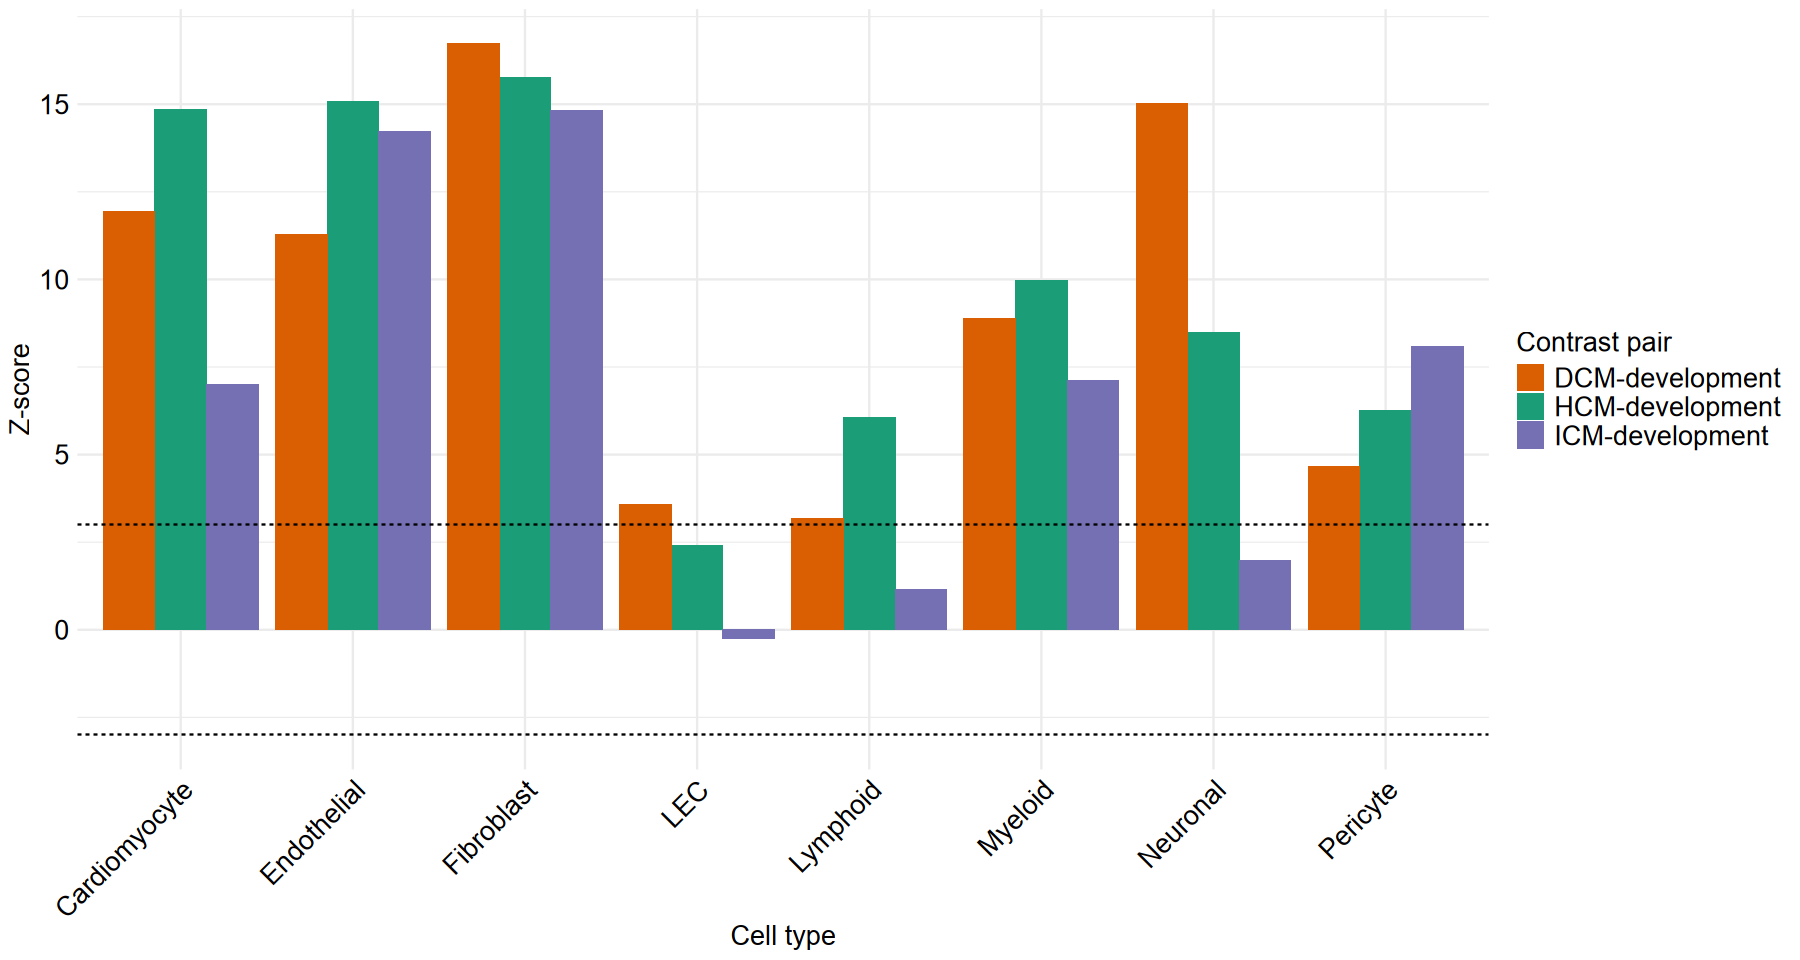

In [5]:
options(repr.plot.width = 15, repr.plot.height = 8)

p1 <- ggplot(data = intersection_df,
       mapping = aes(x = cell_type, y = z_score, fill = contrast_pair)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  scale_fill_manual(values = c(
    "HCM-development"   = "#1B9E77",
    "DCM-development"     = "#D95F02",
    "ICM-development" = "#7570B3"
  )) +
  theme_minimal() + geom_hline(yintercept = 3, linetype = "dashed", color = "black") +
  geom_hline(yintercept = -3, linetype = "dashed", color = "black") +
  labs(x = "Cell type", y = "Z-score", fill = "Contrast pair") +
theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16, color = "black"), 
         plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
         axis.title.x = element_text(size = 16, color = "black"),
         axis.title.y = element_text(size = 16, color = "black"),
         axis.text.x = element_text(size = 16, color = "black", angle = 45, hjust = 1),
         axis.text.y = element_text(size = 16, color = "black"),
	 strip.text = element_text(size = 18, color = "black"))

ggsave(plot = p1, filename = "04B_non_binarized_disease_fetal_z_score_plot.pdf", width = 15, height = 8)

p1